# PSE vs Conflict — improved free μ/σ/λ psychometric refits

Replicates `aggregated_mu_vs_models_freeMuSigmaLambda_sem_clean` but **refits each
participant better**:

* **Lognormal psychometric** — cumulative Gaussian on `log(testDurS / standardDur)`:
  `p(choose test) = λ/2 + (1−λ)·Φ((x − μ)/σ)`, with **μ, σ, λ all free per condition**.
* **Canonical conflict snapping** — recorded `conflictDur` is jittered per participant
  (up to 13 near-duplicate values around the 7 design levels). We snap each trial to the
  nearest canonical level so every level pools all its trials into one curve, and data /
  models / participants share identical conflict labels. This is the main accuracy gain.
* **Stronger optimizer** — curated + random multi-starts of `L-BFGS-B` on a binomial NLL,
  then a Nelder–Mead polish (no `curve_fit`).
* Same procedure for **real data** and **model-simulated** choices, then mean ± SEM across
  participants (n = 11).

Fits are cached to `psychometric_fits_freeMuSigmaLambda_better_{real,simulated}/`.

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import loadData
from free_psychometric_refits import (
    pf_input_from_durations,   # log(test/standard) for pf_mode='lognormal'
    psychometric_pf,           # lambda/2 + (1-lambda)*norm.cdf((x-mu)/sigma)
    mu_to_shift_s,             # standard_s*(exp(mu)-1) in lognormal mode
    sigma_to_plot_units,
    simulated_csv_path,
    DEFAULT_MAIN_MODELS,
    DEFAULT_SIM_VARIANTS,
)

In [2]:
FONT = 18
plt.rcParams.update({
    'font.size': FONT, 'axes.labelsize': FONT, 'axes.titlesize': FONT + 2,
    'xtick.labelsize': FONT, 'ytick.labelsize': FONT, 'legend.fontsize': FONT,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.linewidth': 1.5, 'lines.linewidth': 2.0, 'lines.markersize': 8,
    'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
    'xtick.major.size': 6, 'ytick.major.size': 6,
    'legend.frameon': True, 'legend.framealpha': 0.8, 'legend.edgecolor': 'black',
    'figure.dpi': 100, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'savefig.pad_inches': 0.1, 'axes.grid': False,
})

In [3]:
# ── Configuration ────────────────────────────────────────────
STANDARD_S = 0.5
PF_MODE = 'lognormal'                       # log cumulative Gaussian on log(test/standard)
PIDS = ['as', 'dt', 'hh', 'ip', 'ln2', 'mh', 'ml', 'mt', 'oy', 'qs', 'sx']  # n = 11
MAIN_MODELS = DEFAULT_MAIN_MODELS           # ['lognorm', 'fusionOnlyLogNorm', 'switchingFree']

# Model predictions come from the FREE-sigma generative fits (model_fits/P0x), simulated
# into simulated_data_freeSigma/ by _gen_freesigma_sims.py. With free sensory sigma the
# fits use a single shared lapse (LapseFix), matching the manuscript's single-lambda
# model-comparison table; p_c is no longer pinned by the fixed-sigma parameterization.
SIM_DIR = 'simulated_data_freeSigma'
MODEL_VARIANTS = ['LapseFix_sharedPrior']

CANONICAL_CONFLICTS = np.array([-0.25, -0.17, -0.08, 0.0, 0.08, 0.17, 0.25])
NOISE_LEVELS = [0.1, 1.2]

OUT_REAL = Path('psychometric_fits_freeMuSigmaLambda_better_real')
OUT_SIM = Path('psychometric_fits_freeMuSigmaLambda_better_freeSigmaModel_simulated')
FORCE_REFIT = 0                          # recompute the better fits from scratch

# Optimizer budget for the improved fit (more starts -> fewer jagged local optima).
N_RANDOM_STARTS = 40
RNG_SEED = 0

In [4]:
# ── Lognormal PF fit per condition (free mu, sigma, lambda) ──────────────────
PF_BOUNDS = [(-1.0, 1.0), (0.01, 3.0), (0.0, 0.25)]   # mu, sigma, lambda (lognormal mode)


def snap_conflict(values):
    """Snap recorded conflictDur to the nearest canonical design level."""
    values = np.asarray(values, dtype=float)
    idx = np.abs(values[:, None] - CANONICAL_CONFLICTS[None, :]).argmin(axis=1)
    return CANONICAL_CONFLICTS[idx]


def condition_counts(sub):
    """Aggregate one condition's trials into (unique pf_x, n_chose_test, n_total)."""
    df = sub.copy()
    if 'chose_test' in df.columns:
        chose = (df['chose_test'].astype(float) > 0.5).astype(float)
    elif 'responses' in df.columns:
        chose = (df['responses'].astype(float) == 2).astype(float)
    else:
        raise ValueError('Data must contain chose_test or responses.')
    pf_x = pf_input_from_durations(df['testDurS'], df['standardDur'], pf_mode=PF_MODE)
    chose = chose.to_numpy()
    mask = np.isfinite(pf_x) & np.isfinite(chose)
    pf_x, chose = pf_x[mask], chose[mask]
    ux, inv = np.unique(np.round(pf_x, 12), return_inverse=True)
    n_total = np.bincount(inv).astype(float)
    n_chose = np.bincount(inv, weights=chose).astype(float)
    return ux, n_chose, n_total


def _binom_nll(params, pf_x, n_chose, n_total):
    mu, sigma, lam = params
    if sigma <= 0 or lam < 0 or lam >= 0.5:
        return 1e10
    p = psychometric_pf(pf_x, mu, sigma, lam)
    p = np.clip(p, 1e-9, 1.0 - 1e-9)
    return -float(np.sum(n_chose * np.log(p) + (n_total - n_chose) * np.log1p(-p)))


def _clip(x0):
    return np.array([min(max(v, lo + 1e-6), hi - 1e-6)
                     for v, (lo, hi) in zip(x0, PF_BOUNDS)], dtype=float)


def fit_pf_counts_better(pf_x, n_chose, n_total, n_random=N_RANDOM_STARTS, seed=RNG_SEED):
    """Free mu/sigma/lambda lognormal PF fit with strong multi-start + polish."""
    pf_x = np.asarray(pf_x, float); n_chose = np.asarray(n_chose, float)
    n_total = np.asarray(n_total, float)
    m = np.isfinite(pf_x) & np.isfinite(n_chose) & np.isfinite(n_total) & (n_total > 0)
    pf_x, n_chose, n_total = pf_x[m], n_chose[m], n_total[m]
    if len(np.unique(pf_x)) < 3:
        return dict(mu=np.nan, sigma=np.nan, lambda_=np.nan, nll=np.nan,
                    success=False, n_trials=float(n_total.sum()))

    prop = np.clip(n_chose / n_total, 0, 1)
    order = np.argsort(pf_x)
    xs, ps = pf_x[order], prop[order]
    # mu guess: linear-interpolate where the proportion crosses 0.5
    if ps.min() <= 0.5 <= ps.max():
        mu_guess = float(np.interp(0.5, ps, xs))
    else:
        mu_guess = float(xs[np.argmin(np.abs(ps - 0.5))])
    sigma_guess = float(max(np.nanstd(pf_x), 0.05))

    rng = np.random.default_rng(seed)
    # deterministic grid over (mu, sigma, lambda) + the data-driven guess
    mu_seeds = [mu_guess, 0.0]
    sigma_seeds = [0.05, 0.10, 0.20, 0.40, 0.80, 1.20]
    lam_seeds = [0.01, 0.05]
    curated = [[mu_guess, sigma_guess, 0.02]]
    curated += [[mu, sig, lam] for mu in mu_seeds for sig in sigma_seeds for lam in lam_seeds]
    randoms = [[rng.uniform(-0.5, 0.5), rng.uniform(0.05, 1.2), rng.uniform(0.0, 0.15)]
               for _ in range(n_random)]

    best = None
    for x0 in curated + randoms:
        try:
            res = minimize(_binom_nll, _clip(x0), args=(pf_x, n_chose, n_total),
                           bounds=PF_BOUNDS, method='L-BFGS-B')
        except Exception:
            continue
        if np.isfinite(res.fun) and (best is None or res.fun < best.fun):
            best = res
    if best is None:
        return dict(mu=np.nan, sigma=np.nan, lambda_=np.nan, nll=np.nan,
                    success=False, n_trials=float(n_total.sum()))

    # Nelder-Mead polish around the best L-BFGS-B solution.
    try:
        pol = minimize(_binom_nll, best.x, args=(pf_x, n_chose, n_total),
                       method='Nelder-Mead',
                       options=dict(xatol=1e-7, fatol=1e-7, maxiter=2000))
        if np.isfinite(pol.fun) and pol.fun < best.fun:
            cand = _clip(pol.x)
            if _binom_nll(cand, pf_x, n_chose, n_total) <= best.fun:
                best = pol
    except Exception:
        pass

    mu, sigma, lam = _clip(best.x)
    return dict(mu=float(mu), sigma=float(sigma), lambda_=float(lam),
                nll=float(best.fun), success=bool(best.success),
                n_trials=float(n_total.sum()))


def fit_free_table(data):
    """Per (noise x canonical-conflict) free PF fit -> tidy DataFrame."""
    df = data.copy()
    df['conflict_snap'] = snap_conflict(df['conflictDur'].astype(float))
    rows = []
    for noise in NOISE_LEVELS:
        nm = np.isclose(df['audNoise'].astype(float), noise)
        for conflict in CANONICAL_CONFLICTS:
            sub = df[nm & (df['conflict_snap'] == conflict)]
            if sub.empty:
                continue
            ux, nc, nt = condition_counts(sub)
            fit = fit_pf_counts_better(ux, nc, nt)
            rows.append(dict(
                audioNoise=float(noise), conflict=float(conflict),
                conflict_ms=int(round(conflict * 1000)),
                n_trials=int(fit['n_trials']),
                mu=fit['mu'], sigma=fit['sigma'], lambda_=fit['lambda_'],
                nll=fit['nll'], success=fit['success'],
                mu_shift_s=mu_to_shift_s(fit['mu'], STANDARD_S, PF_MODE),
                mu_shift_ms=mu_to_shift_s(fit['mu'], STANDARD_S, PF_MODE) * 1000,
                sigma_plot=sigma_to_plot_units(fit['sigma'], STANDARD_S, PF_MODE),
            ))
    return pd.DataFrame(rows)

In [5]:
# ── Cached fit drivers (real + simulated) ────────────────────────────
def _save(path, fit_df, metadata):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(
        {'metadata': metadata, 'fitParamsByCondition': fit_df.to_dict(orient='records')},
        indent=2))


def _load(path):
    return pd.DataFrame(json.loads(path.read_text())['fitParamsByCondition'])


def fit_real_pid(pid, force=FORCE_REFIT):
    out = OUT_REAL / pid / f'{pid}_psychometricFits.json'
    if out.exists() and not force:
        return _load(out)
    # loadData builds log(conflictDur)/log(standardDur) helper columns we never use;
    # conflictDur == 0 (and negatives) make those log(0)/log(<0) -> harmless inf/nan.
    with np.errstate(divide='ignore', invalid='ignore'):
        data, data_name = loadData.loadData(f'{pid}_all.csv', verbose=False)
    fit_df = fit_free_table(data)
    fit_df.insert(0, 'pid', pid)
    _save(out, fit_df, dict(participantID=pid, dataName=data_name, pf_mode=PF_MODE,
                            parameterization='free_mu_sigma_lambda_per_condition',
                            conflict='snapped_to_canonical', fitter='multistart_lbfgsb+neldermead'))
    return fit_df


def fit_sim_pid(pid, model, force=FORCE_REFIT):
    out = OUT_SIM / pid / f'{pid}_{model}_psychometricFits.json'
    if out.exists() and not force:
        return _load(out)
    sim_path = simulated_csv_path(pid, model, variants=MODEL_VARIANTS, sim_dir=SIM_DIR)
    if sim_path is None:
        return pd.DataFrame()
    fit_df = fit_free_table(pd.read_csv(sim_path))
    fit_df.insert(0, 'pid', pid)
    fit_df.insert(1, 'model', model)
    _save(out, fit_df, dict(participantID=pid, modelType=model, simulatedData=str(sim_path),
                            pf_mode=PF_MODE, parameterization='free_mu_sigma_lambda_per_condition',
                            conflict='snapped_to_canonical', fitter='multistart_lbfgsb+neldermead'))
    return fit_df


def aggregate(fit_df, value_col='mu_shift_s'):
    keys = ['audioNoise', 'conflict']
    if 'model' in fit_df.columns:
        keys = ['model'] + keys
    agg = fit_df.groupby(keys)[value_col].agg(['mean', 'std', 'count']).reset_index()
    agg['sem'] = agg['std'] / np.sqrt(agg['count'])
    return agg

In [6]:
# ── Run the refits ─────────────────────────────────────────────
data_frames, model_frames, missing = [], [], []
for pid in PIDS:
    data_frames.append(fit_real_pid(pid))
    for model in MAIN_MODELS:
        mf = fit_sim_pid(pid, model)
        (model_frames if not mf.empty else missing).append(mf if not mf.empty else (pid, model))
    print(f'  fitted {pid}')

data_pp = pd.concat(data_frames, ignore_index=True)
model_pp = pd.concat([m for m in model_frames], ignore_index=True)

data_agg = aggregate(data_pp, 'mu_shift_s')
model_agg = aggregate(model_pp, 'mu_shift_s')
sigma_agg = aggregate(data_pp, 'sigma_plot')
lambda_agg = aggregate(data_pp, 'lambda_')

print(f'\nParticipants: {len(PIDS)} | data rows: {len(data_pp)} | model rows: {len(model_pp)}')
if missing:
    print('Missing simulated CSVs:', missing)
print('\nData PSE shift (ms) mean ± SEM:')
print((data_agg.assign(mean_ms=data_agg['mean']*1000, sem_ms=data_agg['sem']*1000)
       [['audioNoise', 'conflict', 'mean_ms', 'sem_ms', 'count']]).to_string(index=False))
print('\nData PF sigma (log units) mean ± SEM:')
print(sigma_agg[['audioNoise', 'conflict', 'mean', 'sem']].to_string(index=False))

  fitted as
  fitted dt
  fitted hh
  fitted ip
  fitted ln2
  fitted mh
  fitted ml
  fitted mt
  fitted oy
  fitted qs
  fitted sx

Participants: 11 | data rows: 154 | model rows: 462

Data PSE shift (ms) mean ± SEM:
 audioNoise  conflict     mean_ms    sem_ms  count
        0.1     -0.25  -44.485809 27.286081     11
        0.1     -0.17  -30.748390 14.729456     11
        0.1     -0.08    2.490011 12.177840     11
        0.1      0.00   -4.157357 15.071493     11
        0.1      0.08    4.700251 10.914765     11
        0.1      0.17   22.089955 15.977645     11
        0.1      0.25   34.089259 18.023915     11
        1.2     -0.25 -154.639539 32.666619     11
        1.2     -0.17  -98.132577 14.702852     11
        1.2     -0.08    5.902229 26.429999     11
        1.2      0.00   22.195820 19.900039     11
        1.2      0.08   88.552227 24.219993     11
        1.2      0.17   83.670024 16.944295     11
        1.2      0.25   90.392895 26.426471     11

Data PF sigma (

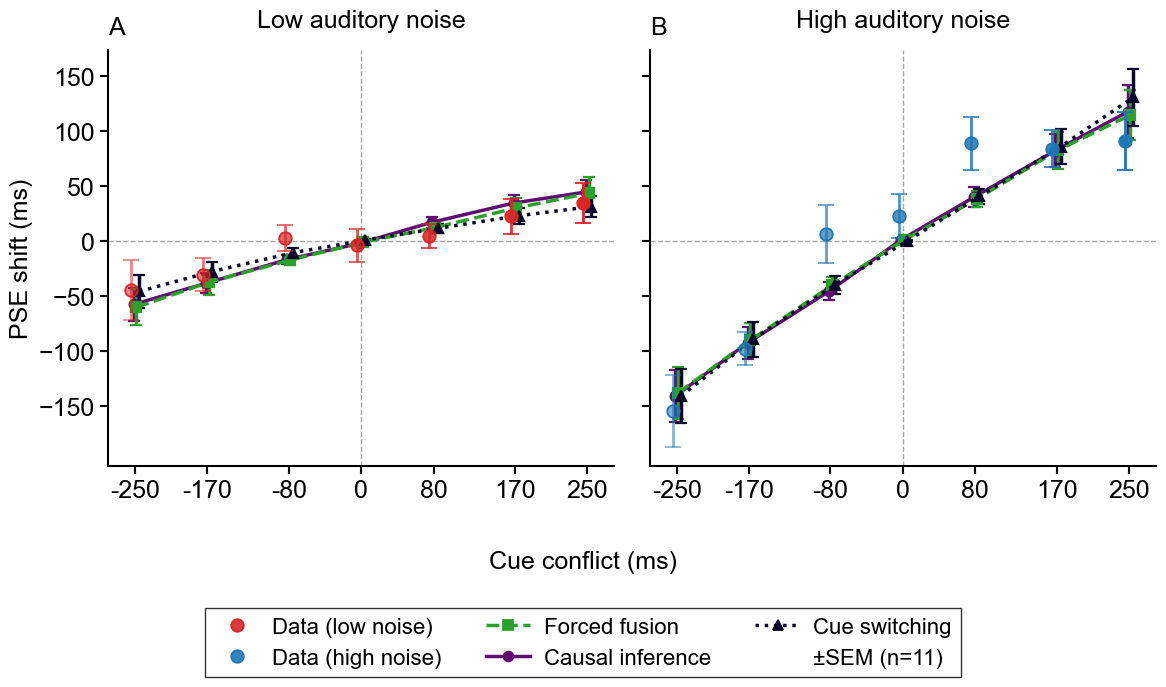

Saved aggregated_mu_vs_models_freeMuSigmaLambda_sem_better_freeSigmaModel.png/.pdf/.svg


In [7]:
# ── Plot: free μ/σ/λ lognormal PF, mean ± SEM (replicates the clean figure) ──────
DATA_BASE = {0.1: '#d62728', 1.2: '#1f77b4'}
MODEL_DISPLAY = {'lognorm': 'Causal inference', 'fusionOnlyLogNorm': 'Forced fusion',
                 'switchingFree': 'Cue switching'}
MODEL_STYLE = {'lognorm': dict(ls='-', mk='o'), 'fusionOnlyLogNorm': dict(ls='--', mk='s'),
               'switchingFree': dict(ls=':', mk='^')}
MODEL_COLORS = {'fusionOnlyLogNorm': '#2ca02c', 'lognorm': '#600c70', 'switchingFree': '#080529'}

audio_levels = sorted(data_agg['audioNoise'].unique())
panel_titles = ['A', 'B']
model_names = [m for m in MAIN_MODELS if m in model_agg['model'].unique()]
all_series = ['__data__'] + model_names
mid = (len(all_series) - 1) / 2
offsets = {s: (i - mid) * 3.0 for i, s in enumerate(all_series)}

fig, axes = plt.subplots(1, len(audio_levels), figsize=(12, 6), sharey=True)
if len(audio_levels) == 1:
    axes = [axes]

from matplotlib.lines import Line2D
handles, labels, models_done = [], [], set()

for pi, (ax, noise) in enumerate(zip(axes, audio_levels)):
    sd = data_agg[data_agg['audioNoise'] == noise].sort_values('conflict')
    x = sd['conflict'].to_numpy(float) * 1000
    y = sd['mean'].to_numpy(float) * 1000
    yerr = sd['sem'].to_numpy(float) * 1000
    base_rgb = mcolors.to_rgb(DATA_BASE[noise])
    # Keep a high alpha floor so even the most-negative-conflict points stay visible.
    # Each marker also gets a full-opacity colored outline, so a faint fill still reads
    # as a crisp point sitting on top of the model lines.
    alphas = np.linspace(0.55, 1.0, len(x))
    for k in range(len(x)):
        rgba = (*base_rgb, alphas[k])
        ax.errorbar(x[k] + offsets['__data__'], y[k], yerr=[[yerr[k]], [yerr[k]]],
                    color=rgba, fmt='o', capsize=6, lw=2.0, capthick=1.8,
                    markersize=9, zorder=7, markerfacecolor=rgba,
                    markeredgecolor=(*base_rgb, 1.0), markeredgewidth=1.3)
    if pi == 0:
        r, b = mcolors.to_rgb(DATA_BASE[0.1]), mcolors.to_rgb(DATA_BASE[1.2])
        handles += [Line2D([0], [0], marker='o', lw=0, markersize=9,
                           markerfacecolor=(*r, 0.9), markeredgecolor=(*r, 1.0),
                           markeredgewidth=1.3),
                    Line2D([0], [0], marker='o', lw=0, markersize=9,
                           markerfacecolor=(*b, 0.9), markeredgecolor=(*b, 1.0),
                           markeredgewidth=1.3)]
        labels += ['Data (low noise)', 'Data (high noise)']

    for mname in model_names:
        sm = model_agg[(model_agg['audioNoise'] == noise) &
                       (model_agg['model'] == mname)].sort_values('conflict')
        if sm.empty:
            continue
        c = MODEL_COLORS.get(mname, 'gray')
        ls = MODEL_STYLE.get(mname, {}).get('ls', '-')
        mk = MODEL_STYLE.get(mname, {}).get('mk', 'o')
        xm = sm['conflict'].to_numpy(float) * 1000 + offsets.get(mname, 0)
        ym = sm['mean'].to_numpy(float) * 1000
        m_yerr = sm['sem'].to_numpy(float) * 1000
        ax.errorbar(xm, ym, yerr=m_yerr, color=c, linestyle=ls, marker=mk,
                    markerfacecolor=c, markeredgewidth=1.6, capsize=4, lw=2.5,
                    markersize=7, zorder=4)
        if mname not in models_done:
            handles.append(Line2D([0], [0], color=c, ls=ls, marker=mk, markerfacecolor=c,
                                  markeredgewidth=1.3, lw=2.5, markersize=7))
            labels.append(MODEL_DISPLAY.get(mname, mname))
            models_done.add(mname)

    ax.text(0, 200, 'Low auditory noise' if pi == 0 else 'High auditory noise',
            fontsize=FONT, ha='center', va='center')
    ax.axhline(0, color='gray', ls='--', lw=1, alpha=.7)
    ax.axvline(0, color='gray', ls='--', lw=1, alpha=.7)
    ax.set_title(panel_titles[pi], fontsize=FONT, loc='left', pad=12)
    ax.set_xticks([-250, -170, -80, 0, 80, 170, 250])
    ax.set_yticks([-150, -100, -50, 0, 50, 100, 150])
    ax.set_xticklabels([str(t) for t in [-250, -170, -80, 0, 80, 170, 250]], fontsize=FONT - 2)
    ax.tick_params(axis='both', labelsize=FONT)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('PSE shift (ms)', fontsize=FONT)
fig.supxlabel('Cue conflict (ms)', fontsize=FONT, x=0.5)

# ── Bottom legend, 3 columns laid out to match the manuscript figure ──
#   col1: Data (low noise)  / Data (high noise)
#   col2: Forced fusion     / Causal inference
#   col3: Cue switching     / ±SEM (n=...)
# matplotlib fills legend entries column-major, so order handles that way.
hl = dict(zip(labels, handles))
col_order = ['Data (low noise)', 'Data (high noise)',
             'Forced fusion', 'Causal inference', 'Cue switching']
leg_handles = [hl[l] for l in col_order if l in hl]
leg_labels = [l for l in col_order if l in hl]
leg_handles.append(Line2D([], [], color='none'))
leg_labels.append(f'±SEM (n={len(PIDS)})')

# Lay the axes out across the FULL figure first, then hang the legend just below
# the bottom edge. We DON'T reserve space for it via tight_layout(rect=...), so the
# axes keep their full size; savefig(bbox_inches='tight') simply grows the saved
# canvas downward to include the legend instead of squishing the plot.
plt.tight_layout()
leg = fig.legend(leg_handles, leg_labels, loc='upper center', ncol=3,
                 bbox_to_anchor=(0.5, -0.03), columnspacing=2.0, handletextpad=0.6,
                 fontsize=FONT - 2, frameon=True, edgecolor='black', fancybox=False)

stem = 'aggregated_mu_vs_models_freeMuSigmaLambda_sem_better_freeSigmaModel'
save_kw = dict(bbox_inches='tight', bbox_extra_artists=(leg,))
plt.savefig(f'{stem}.png', dpi=200, **save_kw)
plt.savefig(f'{stem}.pdf', dpi=900, format='pdf', **save_kw)
plt.savefig(f'{stem}.svg', format='svg', **save_kw)
plt.show()
print(f'Saved {stem}.png/.pdf/.svg')

## Model discrimination

The PSE-shift panel collapses each model into per-condition μ, so the three models look
near-identical there. The panels below separate them: the **discrimination threshold (σ)**
and **lapse (λ)** the descriptive PF recovers from each model's simulated choices, plus a
**per-participant RMSE** of each model's PSE-shift against the real data.

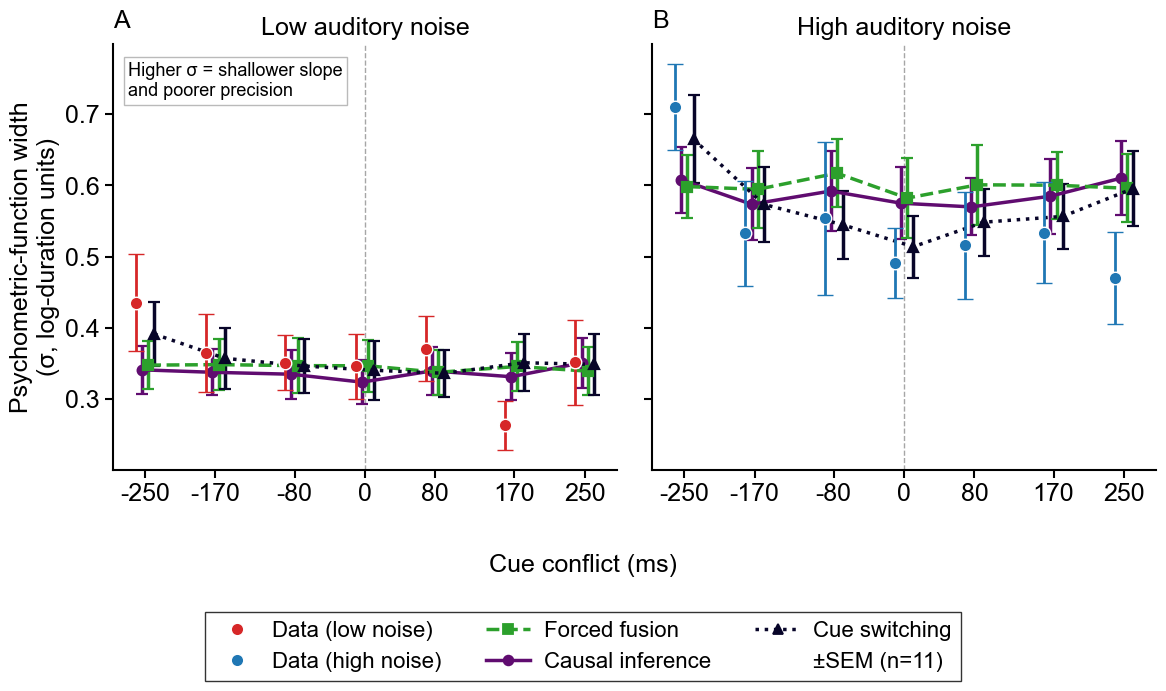

Saved aggregated_sigma_vs_models_freeMuSigmaLambda_sem_better_freeSigmaModel.png/.pdf/.svg


In [8]:
# ── Aggregate sigma & lambda for data and each model ────────────
data_sigma = aggregate(data_pp, 'sigma_plot')
model_sigma = aggregate(model_pp, 'sigma_plot')
data_lambda = aggregate(data_pp, 'lambda_')
model_lambda = aggregate(model_pp, 'lambda_')

# Colour the data by auditory-noise level, consistent with the PSE-shift figure.
DATA_LABEL = {0.1: 'Data (low noise)', 1.2: 'Data (high noise)'}


def two_panel_metric(d_agg, m_agg, ylabel, stem, yticks=None, scale=1.0, note=None):
    """Generic two-panel (low/high noise) metric vs conflict, data + models, mean±SEM."""
    levels = sorted(d_agg['audioNoise'].unique())
    mnames = [m for m in MAIN_MODELS if m in m_agg['model'].unique()]
    series = ['__data__'] + mnames
    mmid = (len(series) - 1) / 2
    off = {s: (i - mmid) * 7.0 for i, s in enumerate(series)}

    fig, axes = plt.subplots(1, len(levels), figsize=(12, 6), sharey=True)
    if len(levels) == 1:
        axes = [axes]
    from matplotlib.lines import Line2D
    hs, ls_, done, data_done = [], [], set(), set()
    for pi, (ax, noise) in enumerate(zip(axes, levels)):
        sd = d_agg[d_agg['audioNoise'] == noise].sort_values('conflict')
        x = sd['conflict'].to_numpy(float) * 1000
        y = sd['mean'].to_numpy(float) * scale
        ye = sd['sem'].to_numpy(float) * scale
        # Colour data by noise (red = low, blue = high), matching the PSE-shift figure;
        # white outline keeps it distinct from the dark model curves and on top of them.
        dcol = DATA_BASE.get(noise, 'black')
        dlab = DATA_LABEL.get(noise, 'Data')
        ax.errorbar(x + off['__data__'], y, yerr=ye, color=dcol, fmt='o',
                    capsize=6, lw=2.0, capthick=1.8, markersize=9, zorder=7,
                    markerfacecolor=dcol, markeredgecolor='white', markeredgewidth=1.0)
        if dlab not in data_done:
            hs.append(Line2D([0], [0], color=dcol, marker='o', lw=0, markersize=9,
                             markerfacecolor=dcol, markeredgecolor='white', markeredgewidth=1.0))
            ls_.append(dlab)
            data_done.add(dlab)
        for mname in mnames:
            sm = m_agg[(m_agg['audioNoise'] == noise) & (m_agg['model'] == mname)].sort_values('conflict')
            if sm.empty:
                continue
            c = MODEL_COLORS.get(mname, 'gray')
            sty = MODEL_STYLE.get(mname, {})
            xm = sm['conflict'].to_numpy(float) * 1000 + off.get(mname, 0)
            ym = sm['mean'].to_numpy(float) * scale
            yem = sm['sem'].to_numpy(float) * scale
            ax.errorbar(xm, ym, yerr=yem, color=c, linestyle=sty.get('ls', '-'),
                        marker=sty.get('mk', 'o'), markerfacecolor=c, markeredgewidth=1.6,
                        capsize=4, lw=2.5, markersize=7, zorder=4)
            if mname not in done:
                hs.append(Line2D([0], [0], color=c, ls=sty.get('ls', '-'), marker=sty.get('mk', 'o'),
                                 markerfacecolor=c, markeredgewidth=1.3, lw=2.5, markersize=7))
                ls_.append(MODEL_DISPLAY.get(mname, mname))
                done.add(mname)
        ax.text(0.5, 1.01, 'Low auditory noise' if pi == 0 else 'High auditory noise',
                transform=ax.transAxes, fontsize=FONT, ha='center', va='bottom')
        ax.axvline(0, color='gray', ls='--', lw=1, alpha=.7)
        ax.set_title(['A', 'B'][pi], fontsize=FONT, loc='left', pad=12)
        ax.set_xticks([-250, -170, -80, 0, 80, 170, 250])
        ax.set_xticklabels([str(t) for t in [-250, -170, -80, 0, 80, 170, 250]], fontsize=FONT - 2)
        if yticks is not None:
            ax.set_yticks(yticks)
        ax.tick_params(axis='both', labelsize=FONT)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    axes[0].set_ylabel(ylabel, fontsize=FONT)
    fig.supxlabel('Cue conflict (ms)', fontsize=FONT, x=0.5)
    if note:
        axes[0].text(0.03, 0.96, note, transform=axes[0].transAxes,
                     fontsize=FONT - 5, ha='left', va='top',
                     bbox=dict(facecolor='white', edgecolor='0.7', alpha=0.9,
                               boxstyle='square,pad=0.25'))

    # ── Bottom legend, 3 columns (filled column-major), matching the PSE figure ──
    #   col1: Data (low noise)  / Data (high noise)
    #   col2: Forced fusion     / Causal inference
    #   col3: Cue switching     / ±SEM (n=...)
    sem_label = f'±SEM (n={len(PIDS)})'
    hmap = dict(zip(ls_, hs))
    hmap[sem_label] = Line2D([], [], color='none')
    col_order = ['Data (low noise)', 'Data (high noise)',
                 'Forced fusion', 'Causal inference', 'Cue switching']
    leg_handles = [hmap[l] for l in col_order if l in hmap]
    leg_labels = [l for l in col_order if l in hmap]
    leg_handles.append(hmap[sem_label])
    leg_labels.append(sem_label)

    # Axes use the full figure; the legend hangs below the bottom edge and
    # savefig(bbox_inches='tight') grows the canvas to fit it (no squishing).
    plt.tight_layout()
    leg = fig.legend(leg_handles, leg_labels, loc='upper center', ncol=3,
                     bbox_to_anchor=(0.5, -0.03), columnspacing=2.0, handletextpad=0.6,
                     fontsize=FONT - 2, frameon=True, edgecolor='black', fancybox=False)
    save_kw = dict(bbox_inches='tight', bbox_extra_artists=(leg,))
    for ext, kw in [('png', dict(dpi=200)), ('pdf', dict(dpi=900, format='pdf')), ('svg', dict(format='svg'))]:
        plt.savefig(f'{stem}.{ext}', **kw, **save_kw)
    plt.show()
    print(f'Saved {stem}.png/.pdf/.svg')


two_panel_metric(data_sigma, model_sigma,
                 'Psychometric-function width\n(σ, log-duration units)',
                 'aggregated_sigma_vs_models_freeMuSigmaLambda_sem_better_freeSigmaModel',
                 note='Higher σ = shallower slope\nand poorer precision')

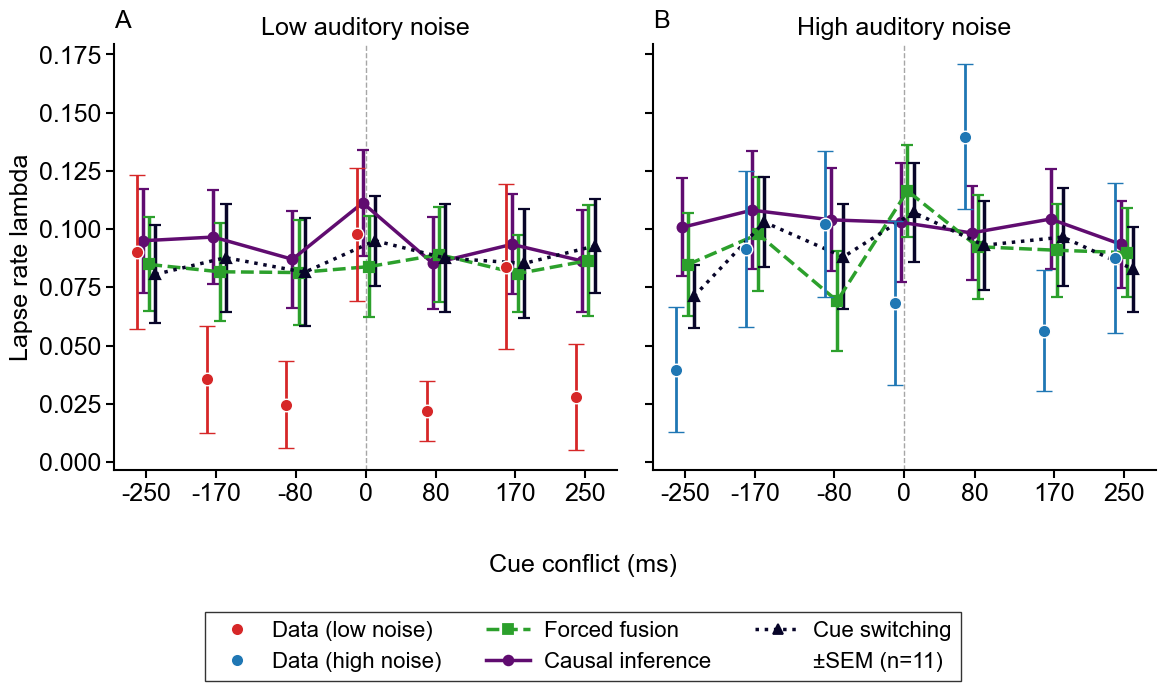

Saved aggregated_lambda_vs_models_freeMuSigmaLambda_sem_better_freeSigmaModel.png/.pdf/.svg


In [9]:
# ── Lapse rate (lambda) vs conflict ─────────────────────────────
two_panel_metric(data_lambda, model_lambda, 'Lapse rate lambda',
                 'aggregated_lambda_vs_models_freeMuSigmaLambda_sem_better_freeSigmaModel')

PSE-shift RMSE vs data (ms), mean ± SEM across participants:
            model      mean      sem  count
          lognorm 53.636574 8.523806     11
fusionOnlyLogNorm 53.679708 8.562219     11
    switchingFree 54.429978 8.811825     11


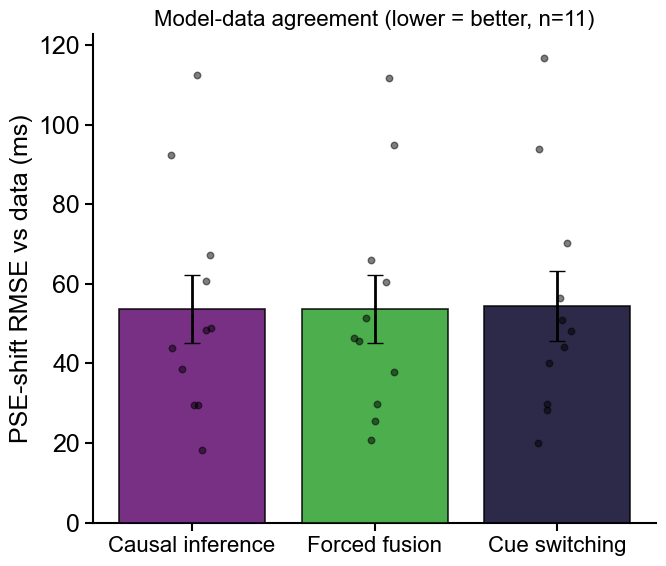

Saved model_vs_data_pse_rmse_better_freeSigmaModel.png/.pdf/.svg


In [10]:
# ── Per-participant model–data agreement (RMSE of PSE shift) ─────────
merged = model_pp.merge(
    data_pp[['pid', 'audioNoise', 'conflict', 'mu_shift_s']],
    on=['pid', 'audioNoise', 'conflict'], suffixes=('', '_data'))
merged['sq_err_ms2'] = ((merged['mu_shift_s'] - merged['mu_shift_s_data']) * 1000) ** 2

per_pid = (merged.groupby(['pid', 'model'])['sq_err_ms2'].mean()
           .pow(0.5).reset_index(name='rmse_ms'))
rmse_agg = per_pid.groupby('model')['rmse_ms'].agg(['mean', 'std', 'count']).reset_index()
rmse_agg['sem'] = rmse_agg['std'] / np.sqrt(rmse_agg['count'])
rmse_agg = rmse_agg.set_index('model').loc[[m for m in MAIN_MODELS if m in rmse_agg['model'].values]].reset_index()

print('PSE-shift RMSE vs data (ms), mean ± SEM across participants:')
print(rmse_agg[['model', 'mean', 'sem', 'count']].to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 6))
xpos = np.arange(len(rmse_agg))
colors = [MODEL_COLORS.get(m, 'gray') for m in rmse_agg['model']]
ax.bar(xpos, rmse_agg['mean'], yerr=rmse_agg['sem'], color=colors, alpha=0.85,
       capsize=6, edgecolor='black', linewidth=1.2, zorder=3)
# overlay individual participants
for j, m in enumerate(rmse_agg['model']):
    pts = per_pid[per_pid['model'] == m]['rmse_ms'].to_numpy()
    ax.scatter(np.full_like(pts, xpos[j]) + np.random.default_rng(j).uniform(-0.12, 0.12, len(pts)),
               pts, color='black', s=22, alpha=0.5, zorder=4)
ax.set_xticks(xpos)
ax.set_xticklabels([MODEL_DISPLAY.get(m, m) for m in rmse_agg['model']], fontsize=FONT - 2)
ax.set_ylabel('PSE-shift RMSE vs data (ms)', fontsize=FONT)
ax.set_title(f'Model-data agreement (lower = better, n={len(PIDS)})', fontsize=FONT - 2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
stem = 'model_vs_data_pse_rmse_better_freeSigmaModel'
for ext, kw in [('png', dict(dpi=200)), ('pdf', dict(dpi=900, format='pdf')), ('svg', dict(format='svg'))]:
    plt.savefig(f'{stem}.{ext}', bbox_inches='tight', **kw)
plt.show()
print(f'Saved {stem}.png/.pdf/.svg')

## Formal model discrimination — trial-level AIC/BIC

The PSE-shift means are model-invariant (all three models fit the same data reproduce the
same mean bias), so they cannot rank the models. The discrimination lives in the
**trial-level likelihood** of the free-sigma generative fits (`model_fits/P0x`). Below:
per-participant ΔAIC/ΔBIC relative to Causal inference, with the Monte-Carlo noise floor
(AIC SD ≈ 1.9 at nSimul=2000, from `aic_noise_floor_seeds.json`) shown as a reference band.

In [11]:
# ── Load free-sigma generative AIC/BIC for the 3 models x 11 participants ─────
# Match modelComparisonTable_threeModels.ipynb: discover all matching fit JSONs,
# standardize participant IDs from JSON metadata, and keep the lowest-AIC row when
# both anonymous Pxx and participant-named copies exist for the same participant/model.
GEN_VARIANT = 'LapseFix_sharedPrior'

def load_standardized_free_sigma_aic():
    gen_rows = []
    for fp in sorted(Path('model_fits').glob('**/*_fit.json')):
        filename = fp.name
        filename_lower = filename.lower()
        if any(s in filename_lower for s in ('all', 'lnd1', 'ln1', 'loglinear')):
            continue
        if GEN_VARIANT not in filename:
            continue

        parts = filename.replace('.json', '').split('_')
        if len(parts) < 4:
            continue
        model = parts[1]
        if model not in MAIN_MODELS:
            continue

        d = json.loads(fp.read_text())
        k = len(d['fittedParams'])
        log_lik = d['logLikelihood']
        gen_rows.append(dict(
            pid=str(d.get('participantID', parts[0])).lower(),
            file_pid=parts[0],
            model=model,
            AIC=2 * k - 2 * log_lik,
            BIC=d['BIC'],
            logLik=log_lik,
            k=k,
            fit_file=str(fp),
        ))

    gen = pd.DataFrame(gen_rows)
    if gen.empty:
        raise FileNotFoundError('No matching free-sigma generative model fits found.')

    gen = gen[gen['pid'].isin(PIDS)].copy()
    gen = gen.sort_values(['pid', 'model', 'AIC']).drop_duplicates(
        subset=['pid', 'model'], keep='first'
    ).reset_index(drop=True)

    expected = pd.MultiIndex.from_product([PIDS, MAIN_MODELS], names=['pid', 'model'])
    observed = pd.MultiIndex.from_frame(gen[['pid', 'model']])
    missing = expected.difference(observed)
    if len(missing):
        raise FileNotFoundError(f'Missing generative fits: {list(missing)}')

    gen['delta_AIC'] = gen.groupby('pid')['AIC'].transform(lambda x: x - x.min())
    gen['delta_BIC'] = gen.groupby('pid')['BIC'].transform(lambda x: x - x.min())
    gen['delta_LL'] = gen.groupby('pid')['logLik'].transform(lambda x: x.max() - x)
    return gen

gen = load_standardized_free_sigma_aic()

aic = gen.pivot_table(index='pid', columns='model', values='AIC', aggfunc='min').reindex(index=PIDS, columns=MAIN_MODELS)
bic = gen.pivot_table(index='pid', columns='model', values='BIC', aggfunc='min').reindex(index=PIDS, columns=MAIN_MODELS)

# AIC Monte-Carlo noise floor (free-sigma) from the seed-resampling cache, if present.
AIC_NOISE_FLOOR = 1.9
try:
    nf = pd.DataFrame(json.loads(Path('aic_noise_floor_seeds.json').read_text()))
    nf = nf[nf['fit_source'] == 'Free sensory noise']
    if not nf.empty:
        AIC_NOISE_FLOOR = float(nf['AIC_sd'].mean())
except Exception:
    pass

# ΔAIC relative to Causal inference (lognorm); negative = better than causal inference.
REF = 'lognorm'
dAIC = aic.sub(aic[REF], axis=0)
dBIC = bic.sub(bic[REF], axis=0)
wins_aic = aic.idxmin(axis=1).value_counts().reindex(MAIN_MODELS).fillna(0).astype(int)
wins_bic = bic.idxmin(axis=1).value_counts().reindex(MAIN_MODELS).fillna(0).astype(int)

summary = pd.DataFrame({
    'mean_dAIC_vs_causal': dAIC.mean(), 'sem_dAIC': dAIC.sem(),
    'mean_dBIC_vs_causal': dBIC.mean(), 'sem_dBIC': dBIC.sem(),
    'AIC_wins': wins_aic, 'BIC_wins': wins_bic,
}).loc[MAIN_MODELS]
print(f'MC AIC noise floor (SD): {AIC_NOISE_FLOOR:.2f}')
print('\nΔAIC/ΔBIC vs Causal inference (negative = better than causal):')
print(summary.round(2).to_string())

MC AIC noise floor (SD): 1.90

ΔAIC/ΔBIC vs Causal inference (negative = better than causal):
                   mean_dAIC_vs_causal  sem_dAIC  mean_dBIC_vs_causal  sem_dBIC  AIC_wins  BIC_wins
lognorm                           0.00      0.00                 0.00      0.00         1         1
fusionOnlyLogNorm                 0.08      0.77                -4.11      0.80         4         9
switchingFree                    -3.00      1.86                 1.19      1.84         6         1


In [12]:
# -- Compare Pxx-style vs participant-named fit files -------------------------
PID_TO_ANON = {
    "as": "P01",
    "dt": "P02",
    "hh": "P03",
    "ip": "P04",
    "ln2": "P07",
    "mh": "P08",
    "ml": "P09",
    "mt": "P10",
    "oy": "P11",
    "qs": "P12",
    "sx": "P13",
}


def _load_style_fit(fp, pid, model, style):
    if not fp.exists():
        return None
    with open(fp, "r") as f:
        d = json.load(f)
    log_lik = float(d["logLikelihood"])
    k = len(d.get("fittedParams", {}))
    n = int(d.get("nTrials", d.get("n_trials", 0)))
    return {
        "pid": pid,
        "model": model,
        "style": style,
        "logLik": log_lik,
        "k": k,
        "n": n,
        "AIC": 2 * k - 2 * log_lik,
        "BIC": float(d.get("BIC", np.nan)),
        "fit_file": str(fp),
    }


style_records = []
missing_style_files = []
for pid in PIDS:
    anon = PID_TO_ANON[pid]
    for model in MAIN_MODELS:
        candidates = {
            "Pxx": Path("model_fits") / anon / f"{anon}_{model}_{GEN_VARIANT}_fit.json",
            "named": Path("model_fits") / pid / f"{pid}_{model}_{GEN_VARIANT}_fit.json",
        }
        for style, fp in candidates.items():
            rec = _load_style_fit(fp, pid, model, style)
            if rec is None:
                missing_style_files.append({"pid": pid, "model": model, "style": style, "fit_file": str(fp)})
            else:
                style_records.append(rec)

style_fit_long = pd.DataFrame(style_records)
if missing_style_files:
    print("Missing Pxx/named fit files:")
    display(pd.DataFrame(missing_style_files))

style_fit_wide = (
    style_fit_long
    .pivot_table(index=["pid", "model"], columns="style", values=["logLik", "AIC", "BIC", "fit_file"], aggfunc="first")
)
style_fit_wide.columns = [f"{style}_{metric}" for metric, style in style_fit_wide.columns]
style_fit_wide = style_fit_wide.reset_index()

for col in ["Pxx_logLik", "named_logLik", "Pxx_AIC", "named_AIC", "Pxx_BIC", "named_BIC"]:
    if col not in style_fit_wide.columns:
        style_fit_wide[col] = np.nan

style_fit_wide["delta_logLik_named_minus_Pxx"] = style_fit_wide["named_logLik"] - style_fit_wide["Pxx_logLik"]
style_fit_wide["delta_AIC_named_minus_Pxx"] = style_fit_wide["named_AIC"] - style_fit_wide["Pxx_AIC"]
style_fit_wide["delta_BIC_named_minus_Pxx"] = style_fit_wide["named_BIC"] - style_fit_wide["Pxx_BIC"]
style_fit_wide["higher_logLik_style"] = np.select(
    [
        style_fit_wide["delta_logLik_named_minus_Pxx"] > 0,
        style_fit_wide["delta_logLik_named_minus_Pxx"] < 0,
    ],
    ["named", "Pxx"],
    default="tie",
)

numeric_cols = [
    "Pxx_logLik", "named_logLik", "delta_logLik_named_minus_Pxx",
    "Pxx_AIC", "named_AIC", "delta_AIC_named_minus_Pxx",
    "Pxx_BIC", "named_BIC", "delta_BIC_named_minus_Pxx",
]
comparison_display = style_fit_wide[[
    "pid", "model", "Pxx_logLik", "named_logLik", "delta_logLik_named_minus_Pxx",
    "higher_logLik_style", "Pxx_AIC", "named_AIC", "delta_AIC_named_minus_Pxx",
    "Pxx_fit_file", "named_fit_file",
]].copy()
for col in numeric_cols:
    if col in comparison_display.columns:
        comparison_display[col] = comparison_display[col].round(3)

print("Pxx-style vs named-style fits. Higher logLik is better; positive delta favors named-style files.")
display(comparison_display.sort_values(["pid", "model"]))

style_overall_loglik = (
    style_fit_long
    .groupby("style", as_index=False)
    .agg(total_logLik=("logLik", "sum"), mean_logLik=("logLik", "mean"), total_AIC=("AIC", "sum"), n_fits=("logLik", "size"))
)
style_by_model_loglik = (
    style_fit_long
    .groupby(["model", "style"], as_index=False)
    .agg(total_logLik=("logLik", "sum"), mean_logLik=("logLik", "mean"), total_AIC=("AIC", "sum"), n_fits=("logLik", "size"))
)
delta_by_model = (
    style_fit_wide
    .groupby("model", as_index=False)
    .agg(
        total_delta_logLik_named_minus_Pxx=("delta_logLik_named_minus_Pxx", "sum"),
        mean_delta_logLik_named_minus_Pxx=("delta_logLik_named_minus_Pxx", "mean"),
        named_higher_count=("higher_logLik_style", lambda s: (s == "named").sum()),
        Pxx_higher_count=("higher_logLik_style", lambda s: (s == "Pxx").sum()),
        n_pairs=("delta_logLik_named_minus_Pxx", "count"),
    )
)

for df in [style_overall_loglik, style_by_model_loglik, delta_by_model]:
    for col in df.select_dtypes(include=["float", "number"]).columns:
        df[col] = df[col].round(3)

print()
print("Overall log-likelihood by file style:")
display(style_overall_loglik.sort_values("style"))

print()
print("Overall log-likelihood by model and file style:")
display(style_by_model_loglik.sort_values(["model", "style"]))

print()
print("Named minus Pxx log-likelihood differences by model:")
display(delta_by_model.sort_values("model"))




Pxx-style vs named-style fits. Higher logLik is better; positive delta favors named-style files.


,pid,model,Pxx_logLik,named_logLik,delta_logLik_named_minus_Pxx,higher_logLik_style,Pxx_AIC,named_AIC,delta_AIC_named_minus_Pxx,Pxx_fit_file,named_fit_file
0,as,fusionOnlyLogNorm,-1119.219,-1118.917,0.302,named,2246.437,2245.833,-0.604,model_fits/P01/P01_fusionOnlyLogNorm_LapseFix_...,model_fits/as/as_fusionOnlyLogNorm_LapseFix_sh...
1,as,lognorm,-1119.374,-1118.300,1.075,named,2248.749,2246.599,-2.149,model_fits/P01/P01_lognorm_LapseFix_sharedPrio...,model_fits/as/as_lognorm_LapseFix_sharedPrior_...
2,as,switchingFree,-1119.544,-1119.731,-0.187,Pxx,2251.088,2251.462,0.374,model_fits/P01/P01_switchingFree_LapseFix_shar...,model_fits/as/as_switchingFree_LapseFix_shared...
3,dt,fusionOnlyLogNorm,-1270.058,-1270.214,-0.156,Pxx,2548.116,2548.429,0.313,model_fits/P02/P02_fusionOnlyLogNorm_LapseFix_...,model_fits/dt/dt_fusionOnlyLogNorm_LapseFix_sh...
4,dt,lognorm,-1269.773,-1269.811,-0.038,Pxx,2549.546,2549.622,0.075,model_fits/P02/P02_lognorm_LapseFix_sharedPrio...,model_fits/dt/dt_lognorm_LapseFix_sharedPrior_...
5,dt,switchingFree,-1268.820,-1268.734,0.086,named,2549.640,2549.467,-0.173,model_fits/P02/P02_switchingFree_LapseFix_shar...,model_fits/dt/dt_switchingFree_LapseFix_shared...
6,hh,fusionOnlyLogNorm,-594.016,-592.828,1.188,named,1196.032,1193.656,-2.377,model_fits/P03/P03_fusionOnlyLogNorm_LapseFix_...,model_fits/hh/hh_fusionOnlyLogNorm_LapseFix_sh...
7,hh,lognorm,-591.948,-592.144,-0.197,Pxx,1193.895,1194.288,0.393,model_fits/P03/P03_lognorm_LapseFix_sharedPrio...,model_fits/hh/hh_lognorm_LapseFix_sharedPrior_...
8,hh,switchingFree,-593.538,-591.430,2.108,named,1199.076,1194.860,-4.216,model_fits/P03/P03_switchingFree_LapseFix_shar...,model_fits/hh/hh_switchingFree_LapseFix_shared...
9,ip,fusionOnlyLogNorm,-1198.955,-1198.715,0.240,named,2405.911,2405.431,-0.480,model_fits/P04/P04_fusionOnlyLogNorm_LapseFix_...,model_fits/ip/ip_fusionOnlyLogNorm_LapseFix_sh...



Overall log-likelihood by file style:


,style,total_logLik,mean_logLik,total_AIC,n_fits
0,Pxx,-36902.826,-1118.267,74135.652,33
1,named,-36891.399,-1117.921,74112.797,33



Overall log-likelihood by model and file style:


,model,style,total_logLik,mean_logLik,total_AIC,n_fits
0,fusionOnlyLogNorm,Pxx,-12317.606,-1119.782,24723.213,11
1,fusionOnlyLogNorm,named,-12312.599,-1119.327,24713.198,11
2,lognorm,Pxx,-12301.770,-1118.343,24713.541,11
3,lognorm,named,-12304.916,-1118.629,24719.833,11
4,switchingFree,Pxx,-12283.449,-1116.677,24698.899,11
5,switchingFree,named,-12273.883,-1115.808,24679.767,11



Named minus Pxx log-likelihood differences by model:


,model,total_delta_logLik_named_minus_Pxx,mean_delta_logLik_named_minus_Pxx,named_higher_count,Pxx_higher_count,n_pairs
0,fusionOnlyLogNorm,5.007,0.455,8,3,11
1,lognorm,-3.146,-0.286,4,7,11
2,switchingFree,9.566,0.870,6,5,11


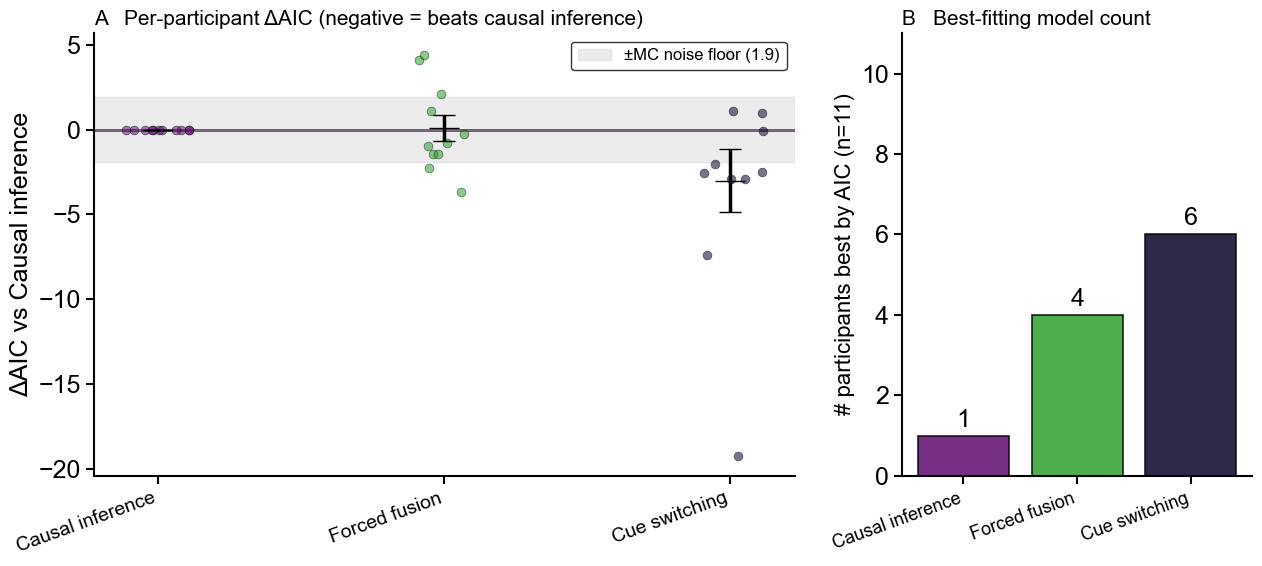

Saved model_discrimination_AIC_freeSigmaModel.png/.pdf/.svg
Forced fusion  vs Causal inference: Wilcoxon p=0.966 (mean ΔAIC=+0.08)
Cue switching  vs Causal inference: Wilcoxon p=0.102 (mean ΔAIC=-3.00)


In [13]:
# ── Plot: model discrimination (ΔAIC per participant + win counts) ──────────
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={'width_ratios': [2, 1]})

order = MAIN_MODELS
xpos = np.arange(len(order))
# noise-floor reference band around 0 (causal inference reference)
axL.axhspan(-AIC_NOISE_FLOOR, AIC_NOISE_FLOOR, color='gray', alpha=0.15, zorder=0,
            label=f'±MC noise floor ({AIC_NOISE_FLOOR:.1f})')
axL.axhline(0, color=MODEL_COLORS['lognorm'], ls='-', lw=2, alpha=0.8, zorder=1)

rng = np.random.default_rng(1)
for j, m in enumerate(order):
    vals = dAIC[m].to_numpy()
    jit = rng.uniform(-0.12, 0.12, len(vals))
    axL.scatter(np.full(len(vals), xpos[j]) + jit, vals, s=40,
                color=MODEL_COLORS.get(m, 'gray'), alpha=0.55, zorder=3,
                edgecolor='black', linewidth=0.5)
    mean, sem = dAIC[m].mean(), dAIC[m].sem()
    axL.errorbar(xpos[j], mean, yerr=sem, fmt='_', color='black', capsize=8,
                 markersize=22, lw=2.5, zorder=4)
axL.set_xticks(xpos)
axL.set_xticklabels([MODEL_DISPLAY[m] for m in order], fontsize=FONT - 4,
                    rotation=20, ha='right')
axL.set_ylabel('ΔAIC vs Causal inference', fontsize=FONT)
axL.set_title('A   Per-participant ΔAIC (negative = beats causal inference)',
              fontsize=FONT - 3, loc='left')
axL.axhline(0, color='gray', lw=0.5)
axL.legend(fontsize=FONT - 6, loc='upper right')
axL.spines['top'].set_visible(False); axL.spines['right'].set_visible(False)

# Right: AIC win counts
wc = wins_aic.loc[order]
axR.bar(xpos, wc.to_numpy(), color=[MODEL_COLORS.get(m, 'gray') for m in order],
        alpha=0.85, edgecolor='black', linewidth=1.2)
for j, v in enumerate(wc.to_numpy()):
    axR.text(xpos[j], v + 0.1, str(int(v)), ha='center', va='bottom', fontsize=FONT)
axR.set_xticks(xpos)
axR.set_xticklabels([MODEL_DISPLAY[m] for m in order], fontsize=FONT - 5,
                    rotation=20, ha='right')
axR.set_ylabel(f'# participants best by AIC (n={len(PIDS)})', fontsize=FONT - 2)
axR.set_title('B   Best-fitting model count', fontsize=FONT - 3, loc='left')
axR.set_ylim(0, len(PIDS))
axR.spines['top'].set_visible(False); axR.spines['right'].set_visible(False)

plt.tight_layout()
stem = 'model_discrimination_AIC_freeSigmaModel'
for ext, kw in [('png', dict(dpi=200)), ('pdf', dict(dpi=900, format='pdf')), ('svg', dict(format='svg'))]:
    plt.savefig(f'{stem}.{ext}', bbox_inches='tight', **kw)
plt.show()
print(f'Saved {stem}.png/.pdf/.svg')

# Paired Wilcoxon: is each alternative better than causal inference across participants?
from scipy.stats import wilcoxon
for m in [x for x in MAIN_MODELS if x != REF]:
    try:
        stat, p = wilcoxon(aic[m], aic[REF])
        print(f'{MODEL_DISPLAY[m]:14} vs Causal inference: Wilcoxon p={p:.3f} '
              f'(mean ΔAIC={dAIC[m].mean():+.2f})')
    except Exception as e:
        print(m, 'wilcoxon failed', e)

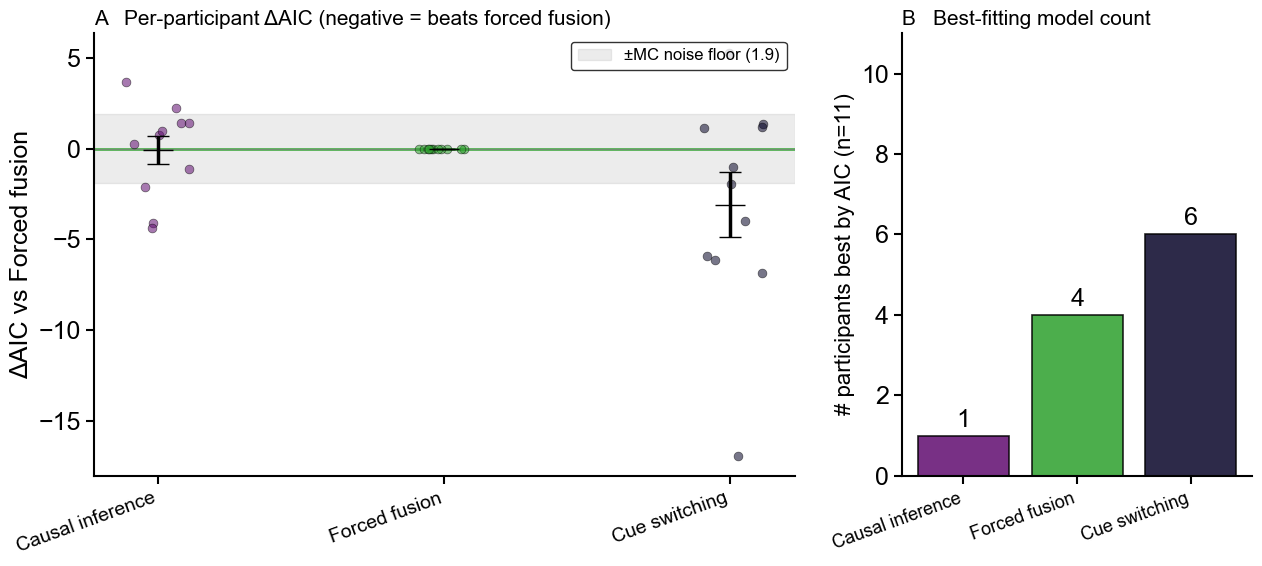

Saved model_discrimination_AIC_vs_forcedFusion_freeSigmaModel.png/.pdf/.svg
Causal inference vs Forced fusion: Wilcoxon p=0.966 (mean ΔAIC=-0.08)
Cue switching    vs Forced fusion: Wilcoxon p=0.147 (mean ΔAIC=-3.09)


In [14]:
# ── Plot: model discrimination (ΔAIC per participant + win counts) vs FORCED FUSION ──
# Same layout as the plot above, but every model is referenced to Forced fusion
# (fusionOnlyLogNorm) instead of Causal inference. Win counts are reference-independent.
REF_FF = 'fusionOnlyLogNorm'
dAIC_ff = aic.sub(aic[REF_FF], axis=0)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={'width_ratios': [2, 1]})

order = MAIN_MODELS
xpos = np.arange(len(order))
# noise-floor reference band around 0 (forced-fusion reference)
axL.axhspan(-AIC_NOISE_FLOOR, AIC_NOISE_FLOOR, color='gray', alpha=0.15, zorder=0,
            label=f'±MC noise floor ({AIC_NOISE_FLOOR:.1f})')
axL.axhline(0, color=MODEL_COLORS[REF_FF], ls='-', lw=2, alpha=0.8, zorder=1)

rng = np.random.default_rng(1)
for j, m in enumerate(order):
    vals = dAIC_ff[m].to_numpy()
    jit = rng.uniform(-0.12, 0.12, len(vals))
    axL.scatter(np.full(len(vals), xpos[j]) + jit, vals, s=40,
                color=MODEL_COLORS.get(m, 'gray'), alpha=0.55, zorder=3,
                edgecolor='black', linewidth=0.5)
    mean, sem = dAIC_ff[m].mean(), dAIC_ff[m].sem()
    axL.errorbar(xpos[j], mean, yerr=sem, fmt='_', color='black', capsize=8,
                 markersize=22, lw=2.5, zorder=4)
axL.set_xticks(xpos)
axL.set_xticklabels([MODEL_DISPLAY[m] for m in order], fontsize=FONT - 4,
                    rotation=20, ha='right')
axL.set_ylabel('ΔAIC vs Forced fusion', fontsize=FONT)
axL.set_title('A   Per-participant ΔAIC (negative = beats forced fusion)',
              fontsize=FONT - 3, loc='left')
axL.axhline(0, color='gray', lw=0.5)
axL.legend(fontsize=FONT - 6, loc='upper right')
axL.spines['top'].set_visible(False); axL.spines['right'].set_visible(False)

# Right: AIC win counts (reference-independent)
wc = wins_aic.loc[order]
axR.bar(xpos, wc.to_numpy(), color=[MODEL_COLORS.get(m, 'gray') for m in order],
        alpha=0.85, edgecolor='black', linewidth=1.2)
for j, v in enumerate(wc.to_numpy()):
    axR.text(xpos[j], v + 0.1, str(int(v)), ha='center', va='bottom', fontsize=FONT)
axR.set_xticks(xpos)
axR.set_xticklabels([MODEL_DISPLAY[m] for m in order], fontsize=FONT - 5,
                    rotation=20, ha='right')
axR.set_ylabel(f'# participants best by AIC (n={len(PIDS)})', fontsize=FONT - 2)
axR.set_title('B   Best-fitting model count', fontsize=FONT - 3, loc='left')
axR.set_ylim(0, len(PIDS))
axR.spines['top'].set_visible(False); axR.spines['right'].set_visible(False)

plt.tight_layout()
stem = 'model_discrimination_AIC_vs_forcedFusion_freeSigmaModel'
for ext, kw in [('png', dict(dpi=200)), ('pdf', dict(dpi=900, format='pdf')), ('svg', dict(format='svg'))]:
    plt.savefig(f'{stem}.{ext}', bbox_inches='tight', **kw)
plt.show()
print(f'Saved {stem}.png/.pdf/.svg')

# Paired Wilcoxon: is each alternative better than forced fusion across participants?
for m in [x for x in MAIN_MODELS if x != REF_FF]:
    try:
        stat, p = wilcoxon(aic[m], aic[REF_FF])
        print(f'{MODEL_DISPLAY[m]:16} vs Forced fusion: Wilcoxon p={p:.3f} '
              f'(mean ΔAIC={dAIC_ff[m].mean():+.2f})')
    except Exception as e:
        print(m, 'wilcoxon failed', e)